# **Amazon Customer Reviews Sentiment Analysis using NLP**

**1. Required Dataset**

Importing libraries required for data manipulation, visualization, and sentiment analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True



* Imported data analysis libraries.




*   Downloaded the VADER lexicon for sentiment analysis.  
*   Imported visualization libraries.





**2. Loading the Dataset**

Reading the CSV file into a pandas DataFrame.

In [2]:
df = pd.read_csv("Reviews.csv")

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...




*   Loaded the dataset.
*   Displayed first five rows.



**3. Exploring the Dataset**

Understanding the dataset structure and identifying the missing values.

In [8]:
df.info()
df.duplicated().sum()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 6262 entries, 0 to 6261
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      6262 non-null   int64 
 1   ProductId               6262 non-null   object
 2   UserId                  6262 non-null   object
 3   ProfileName             6262 non-null   object
 4   HelpfulnessNumerator    6262 non-null   int64 
 5   HelpfulnessDenominator  6262 non-null   int64 
 6   Score                   6262 non-null   int64 
 7   Time                    6262 non-null   int64 
 8   Summary                 6262 non-null   object
 9   Text                    6262 non-null   object
dtypes: int64(5), object(5)
memory usage: 538.1+ KB


,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [6]:
df.duplicated().sum()

np.int64(0)



*   Checking for data types.
*   Identified missing values.


*   checking for duplicates.






**4. Selecting Required Columns**

Keeping only the columns required for sentiment analysis.

In [10]:
df = df[['Score','Summary','Text']]

df.head()

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...




*  Selecting useful columns.
*  Reducing unnecessary data.



**5. Initializing Sentiment Analyzer**

Loading the VADER sentiment analyzer.

In [11]:
sia = SentimentIntensityAnalyzer()



*   Initializing the sentiment analyzer.
*   Preparing for sentiment prediction.


**6. Creating Sentiment Prediction Function**

Classifing each review as Positive, Negative, or Neutral.

In [12]:
def predict_sentiment(review):

    score = sia.polarity_scores(str(review))

    if score['compound'] >= 0.05:
        return "Positive"

    elif score['compound'] <= -0.05:
        return "Negative"

    else:
        return "Neutral"



*   Calculating sentiment score.
*   Classifying review sentiment.


**7. Applying Sentiment Analysis**

Predicting the sentiment of every review.

In [13]:
df['Sentiment'] = df['Text'].apply(predict_sentiment)

df.head()

,Score,Summary,Text,Sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,2,Cough Medicine,If you are looking for the secret ingredient i...,Neutral
4,5,Great taffy,Great taffy at a great price. There was a wid...,Positive




*  Predicting sentiment for every review.
*  Storing the results in a new column.



**8. Visualization**

**1. Sentiment Distribution**

Displaying the number of Positive, Negative, and Neutral reviews.





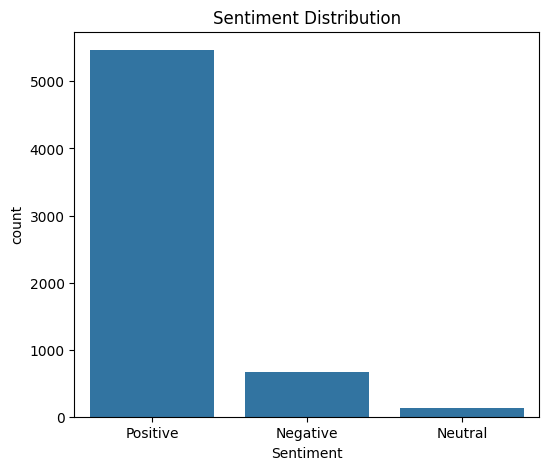

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")
plt.show()



*   Most reviews are positive.
*   Negative reviews are comparatively fewer.



**2. Sentiment Percentage**

Showing the proportion of each sentiment.

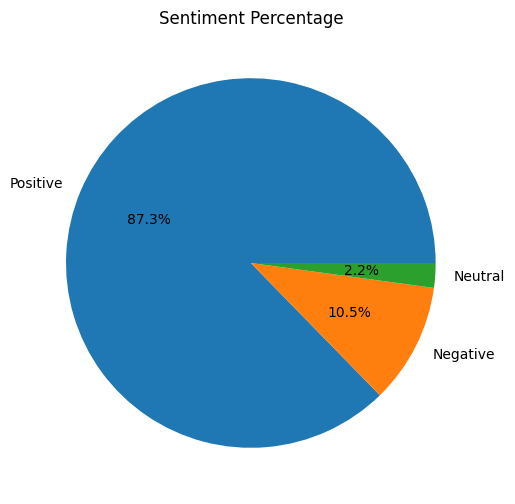

In [15]:
plt.figure(figsize=(6,6))

df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Sentiment Percentage")
plt.show()



*  Positive sentiment dominates.

*  Neutral and negative reviews form a smaller percentage.



**3. Customer Rating Distribution**

Analyzing customer ratings from 1 to 5 stars.

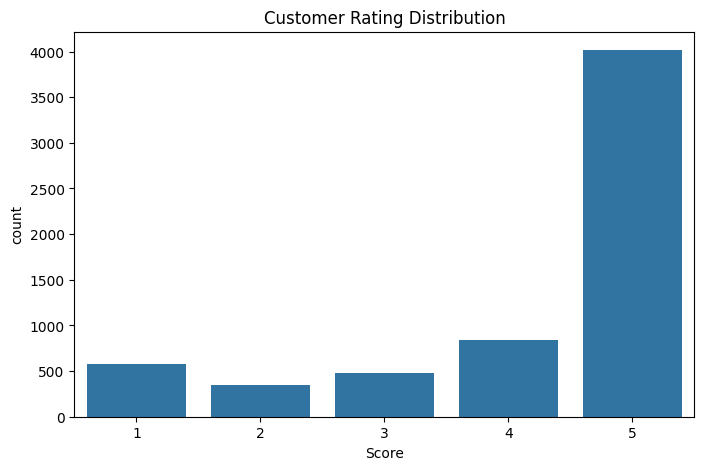

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x='Score', data=df)

plt.title("Customer Rating Distribution")
plt.show()


*   Most customers provided high ratings.
*  Low ratings are comparatively fewer.






**4. Rating vs Sentiment**

Compaing customer ratings with predicted sentiments.

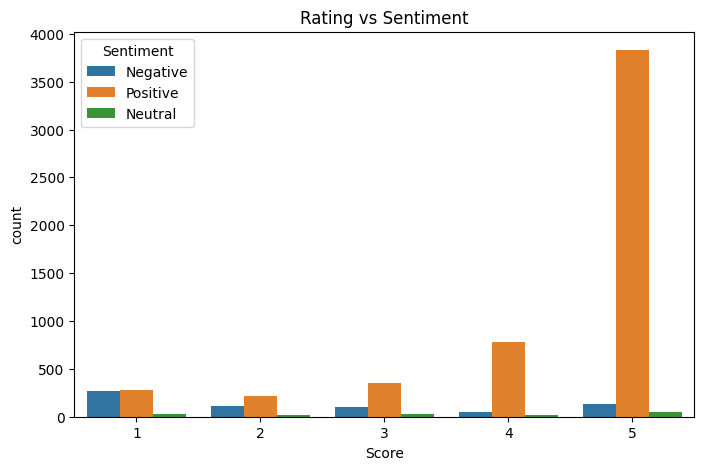

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x='Score', hue='Sentiment', data=df)

plt.title("Rating vs Sentiment")
plt.show()



*   Higher ratings mostly correspond to positive sentiment.
*   Lower ratings are largely associated with negative sentiment.


**5. Review Length Distribution**

Calculating the length of each review and analyze its distribution.


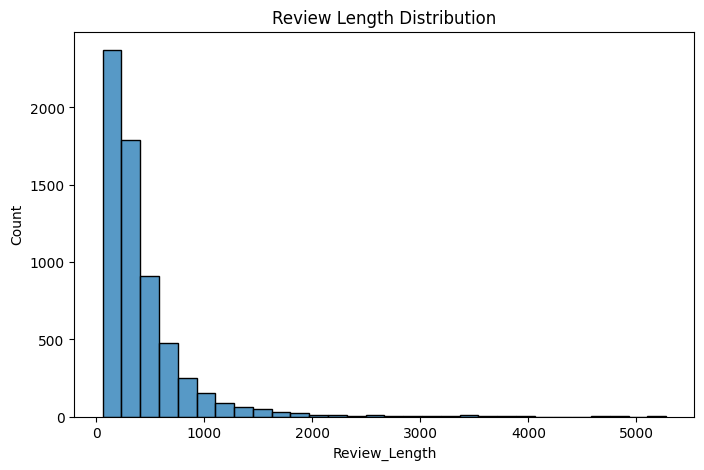

In [18]:
df['Review_Length'] = df['Text'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['Review_Length'], bins=30)

plt.title("Review Length Distribution")

plt.show()



*  Most reviews are short to medium in length.
*  A few customers write detailed reviews.



**9. Installing WordCloud Library**

Installing the wordcloud library to generate visual representations of frequently occurring words.

In [19]:
!pip install wordcloud



*   Installing the WordCloud library.
*   Enabling visualization of frequent words.



**10. Importing WordCloud**

Importing the WordCloud class to create word cloud visualizations.

In [20]:
from wordcloud import WordCloud



*  Importing the required library.
*  Preparing for word cloud generation.



**11. Positive Review Word Cloud**

Generating a word cloud using all reviews classified as Positive.

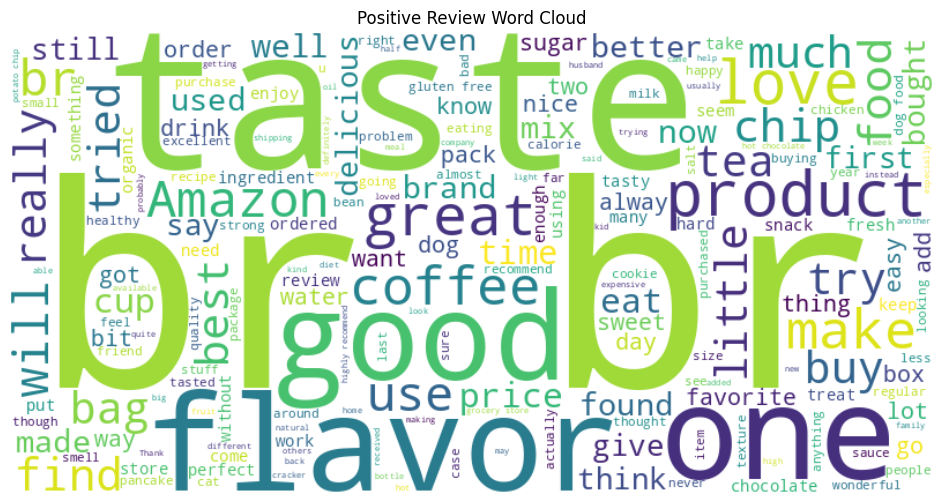

In [21]:
positive_reviews = " ".join(df[df['Sentiment'] == 'Positive']['Text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()



*  Frequently appearing positive words indicate what customers appreciate the most.
*   Positive reviews commonly highlight product flavor, taste, great, and best.


**12. Negative Review Word Cloud**

Generating a word cloud using all reviews classified as Negative.

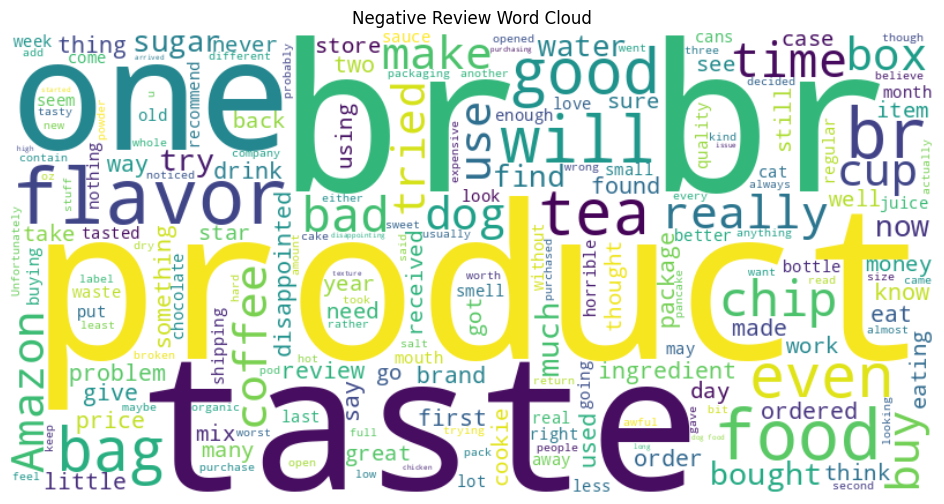

In [22]:
negative_reviews = " ".join(df[df['Sentiment'] == 'Negative']['Text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()



*   Frequently occurring negative words reveal common customer complaints.
*   These insights can help identify areas where products or services may need improvement.



**13. Insights**

1. The majority of customer reviews express positive sentiment, indicating overall customer satisfaction.

2. Products receiving higher ratings generally correspond to positive sentiment predictions.

3. Negative sentiments are mostly associated with lower customer ratings.
Review length varies considerably, with most customers providing concise feedback.

4. Sentiment analysis effectively identifies customer opinions using Natural Language Processing techniques.

5. Businesses can use sentiment insights to improve products, customer service, and marketing strategies.

**14. Conclusion**

This project applied Natural Language Processing (NLP) techniques to analyze Amazon Fine Food Reviews and classify customer opinions into Positive, Negative, and Neutral sentiments using the VADER sentiment analyzer. The analysis revealed customer satisfaction trends and demonstrated how sentiment analysis can support data-driven business decisions.